Train samples: 5216
Val samples: 16
Test samples: 624
Batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([1, 0, 1, 1, 1, 1, 1, 0, 1, 1])


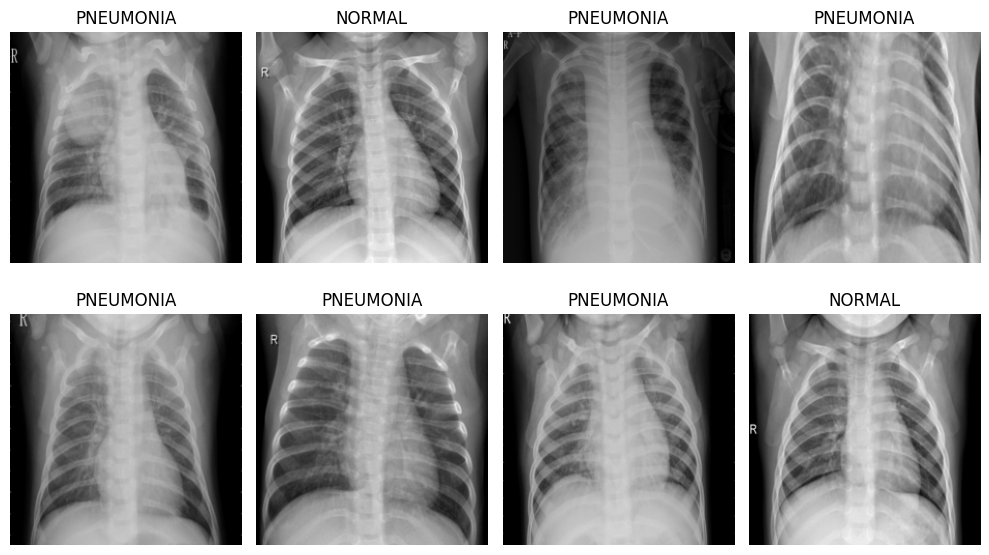

In [2]:
# --- Imports ---
import sys
import os
import torch
import matplotlib.pyplot as plt

# allow notebook to access src/
sys.path.append(os.path.abspath("../src"))

from dataset_generation import get_dataloaders


# --- Load datasets ---
base_path = "../data"

train_loader, val_loader, test_loader = get_dataloaders(base_path, batch_size=32)


# --- Dataset sizes ---
print("Train samples:", len(train_loader.dataset))
print("Val samples:", len(val_loader.dataset))
print("Test samples:", len(test_loader.dataset))


# --- Inspect one batch ---
images, labels = next(iter(train_loader))

print("Batch shape:", images.shape)
print("Labels:", labels[:10])


# --- Function to show images ---
def imshow(img):
    img = img.permute(1, 2, 0)  # CHW -> HWC
    img = img * 0.5 + 0.5       # unnormalize (since we used mean=0.5, std=0.5)
    plt.imshow(img)
    plt.axis("off")


# --- Plot a grid of images ---
plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])
    
    label = "PNEUMONIA" if labels[i].item() == 1 else "NORMAL"
    plt.title(label)

plt.tight_layout()
plt.show()

In [5]:
# =========================
# DenseNet training pipeline
# =========================

import sys
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from torchvision.models import densenet121, DenseNet121_Weights

# allow notebook to access src/
sys.path.append(os.path.abspath("../src"))
from dataset_generation import get_dataloaders


# -------------------------
# Config
# -------------------------
base_path = "../data"
batch_size = 32
num_epochs = 8
lr = 1e-4
weight_decay = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


# -------------------------
# Load data
# -------------------------
train_loader, val_loader, test_loader = get_dataloaders(base_path, batch_size=batch_size)

print("Train samples:", len(train_loader.dataset))
print("Val samples:", len(val_loader.dataset))
print("Test samples:", len(test_loader.dataset))


# -------------------------
# Build DenseNet-121
# -------------------------
#weights = DenseNet121_Weights.DEFAULT
#model = densenet121(weights=weights)

#NOTE: Need to download certificates or something to use pretrained weights
model = densenet121(weights=None)


# replace classifier for binary classification
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 2)

model = model.to(device)


# -------------------------
# Loss / optimizer
# -------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)


# -------------------------
# Evaluation function
# -------------------------
def evaluate_model(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    # AUC only works if both classes are present
    if len(np.unique(all_labels)) == 2:
        auc = roc_auc_score(all_labels, all_probs)
    else:
        auc = np.nan

    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }


# -------------------------
# Training loop
# -------------------------
history = {
    "train_loss": [],
    "test_loss": [],
    "train_acc": [],
    "test_acc": [],
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = float("inf")

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total

    # user asked for train vs test error
    test_metrics = evaluate_model(model, test_loader, criterion, device)
    test_loss = test_metrics["loss"]
    test_acc = test_metrics["accuracy"]

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    # keep best model by validation loss
    val_metrics = evaluate_model(model, val_loader, criterion, device)
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}"
    )

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed/60:.2f} minutes")


# -------------------------
# Load best model (by val loss)
# -------------------------
model.load_state_dict(best_model_wts)


# -------------------------
# Final validation metrics
# -------------------------
final_val_metrics = evaluate_model(model, val_loader, criterion, device)

print("\nFinal validation metrics (best model):")
print(f"Loss      : {final_val_metrics['loss']:.4f}")
print(f"Accuracy  : {final_val_metrics['accuracy']:.4f}")
print(f"Precision : {final_val_metrics['precision']:.4f}")
print(f"Recall    : {final_val_metrics['recall']:.4f}")
print(f"F1        : {final_val_metrics['f1']:.4f}")
print(f"AUC       : {final_val_metrics['auc']:.4f}")
print("Confusion matrix:")
print(final_val_metrics["confusion_matrix"])


# -------------------------
# Plot train vs test error
# -------------------------
train_error = [1 - acc for acc in history["train_acc"]]
test_error = [1 - acc for acc in history["test_acc"]]

plt.figure(figsize=(7, 5))
plt.plot(range(1, num_epochs + 1), train_error, marker="o", label="Train Error")
plt.plot(range(1, num_epochs + 1), test_error, marker="o", label="Test Error")
plt.xlabel("Epoch")
plt.ylabel("Error (1 - Accuracy)")
plt.title("Training vs Test Error")
plt.legend()
plt.grid(True)
plt.show()

Using device: cpu
Train samples: 5216
Val samples: 16
Test samples: 624


KeyboardInterrupt: 